In [3]:
!pip install ipython-sql


   ---------------------------------------- 0.0/44.4 kB ? eta -:--:--
   ---------------------------------------- 44.4/44.4 kB 2.3 MB/s eta 0:00:00


In [5]:
import sqlite3

In [7]:
import pandas as pd

In [9]:
import matplotlib.pyplot as plt

In [11]:
# Step 1: Connect to SQLite DB (will create if doesn't exist)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [19]:
# Load Excel into DataFrame
df = pd.read_excel("Sales.xlsx")

In [21]:
# Load data into a new table called 'sales'
df.to_sql("sales", conn, if_exists="replace", index=False)

99

In [23]:
# Query using SQL
# Query to show the table
query = "SELECT * FROM Sales;"
result_df = pd.read_sql_query(query, conn)

In [25]:
# Display result
print(result_df)

    Row ID+O6G3A1:R6        Order ID           Order Date  \
0               4918  CA-2019-160304  2019-01-01 00:00:00   
1               4919  CA-2019-160304  2019-01-02 00:00:00   
2               4920  CA-2019-160304  2019-01-02 00:00:00   
3               3074  CA-2019-125206  2019-01-03 00:00:00   
4               8604  US-2019-116365  2019-01-03 00:00:00   
..               ...             ...                  ...   
94              8490  CA-2019-158841  2019-02-02 00:00:00   
95              8491  CA-2019-158841  2019-02-02 00:00:00   
96              8513  CA-2019-144645  2019-02-02 00:00:00   
97              5754  CA-2019-118514  2019-02-03 00:00:00   
98              6043  CA-2019-117912  2019-02-04 00:00:00   

              Ship Date       Ship Mode Customer ID      Customer Name  \
0   2019-01-07 00:00:00  Standard Class    BM-11575      Brendan Murry   
1   2019-01-07 00:00:00  Standard Class    BM-11575      Brendan Murry   
2   2019-01-07 00:00:00  Standard Class    BM

In [31]:
# Query for total sales and total profit made
query = "SELECT SUM(Sales) AS Total_Sales, SUM(Profit) AS Total_Profit FROM Sales;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

   Total_Sales  Total_Profit
0    25655.953     5899.2325


In [33]:
# Query for total sales according to region
query = "SELECT Region, SUM(Sales) AS Total_Sales FROM Sales GROUP BY Region ORDER BY Total_Sales DESC;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

    Region  Total_Sales
0    South     9810.316
1  Central     6015.940
2     East     5051.987
3     West     4777.710


In [35]:
# Query for total sales according to cities
query = "SELECT City, SUM(Sales) AS Total_Sales FROM Sales GROUP BY City ORDER BY Total_Sales DESC LIMIT 5;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

           City  Total_Sales
0     Arlington     4861.490
1      Rockford     2067.796
2    Burlington     1672.310
3      Franklin     1671.930
4  Broken Arrow     1604.730


In [71]:
# Query for total sales based on payment mode
query = "SELECT [Payment Mode], SUM(Sales) AS Total_Sales FROM Sales GROUP BY [Payment Mode] ORDER BY Total_Sales DESC;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

  Payment Mode  Total_Sales
0          COD    11937.137
1       Online    11775.070
2        Cards     1943.746


In [37]:
# Query for monthly sales
query = "SELECT strftime('%Y-%m', [Order Date]) AS Month, SUM(Sales) AS Monthly_Sales FROM Sales GROUP BY Month ORDER BY Month;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

     Month  Monthly_Sales
0  2019-01      18616.431
1  2019-02       7039.522


In [39]:
# Query for Total sales based on category and sub category
query = "SELECT Category, [Sub-Category], SUM(Sales) AS Total_Sales FROM Sales GROUP BY Category, [Sub-Category] ORDER BY Total_Sales DESC;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

           Category Sub-Category  Total_Sales
0        Technology     Machines     4749.950
1         Furniture       Tables     2714.469
2        Technology       Phones     2634.360
3   Office Supplies      Storage     2586.850
4         Furniture       Chairs     2468.624
5         Furniture    Bookcases     2313.476
6        Technology  Accessories     2025.738
7   Office Supplies      Binders     1792.696
8   Office Supplies        Paper     1701.696
9         Furniture  Furnishings     1173.356
10       Technology      Copiers      959.968
11  Office Supplies    Envelopes      217.580
12  Office Supplies          Art      153.706
13  Office Supplies       Labels       91.060
14  Office Supplies   Appliances       64.864
15  Office Supplies    Fasteners        7.560


In [55]:
# Query for quantity of product sold 
query = "SELECT [Product Name], SUM(Quantity) AS Total_Quantity_Sold FROM Sales GROUP BY [Product Name] ORDER BY Total_Quantity_Sold DESC;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

                                         Product Name  Total_Quantity_Sold
0                               Ultra Door Push Plate                   14
1               Iceberg Mobile Mega Data/Printer Cart                   13
2                  netTALK DUO VoIP Telephone Service                    9
3                                          Xerox 1959                    9
4               File Shuttle II and Handi-File, Black                    9
..                                                ...                  ...
93                                         Newell 312                    1
94  Logitech 910-002974 M325 Wireless Mouse for We...                    1
95  Fellowes PB500 Electric Punch Plastic Comb Bin...                    1
96            Bevis Round Bullnose 29" High Table Top                    1
97                                    AT&T 1080 Phone                    1

[98 rows x 2 columns]


In [57]:
# Query for total revenue
query = "SELECT SUM(Sales) AS Total_Revenue FROM Sales;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

   Total_Revenue
0      25655.953


In [65]:
# Query for Revenue according to product name and region
query = "SELECT [Product Name], [Region], SUM(Sales) AS Revenue FROM Sales GROUP BY [Product Name], [Region] ORDER BY Revenue DESC;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

                                         Product Name   Region   Revenue
0   HP Designjet T520 Inkjet Large Format Printer ...    South  4749.950
1   Hon Practical Foundations 30 x 60 Training Tab...  Central  1592.850
2   Atlantic Metals Mobile 3-Shelf Bookcases, Cust...  Central  1565.880
3               Iceberg Mobile Mega Data/Printer Cart     East  1564.290
4                                    Nokia Lumia 1020  Central  1439.968
..                                                ...      ...       ...
93                                Bagged Rubber Bands     East     7.560
94                                         Newell 337    South     5.248
95                                         Newell 312     East     4.672
96                                    American Pencil     East     4.660
97                              Avery Durable Binders  Central     1.728

[98 rows x 3 columns]


In [67]:
# Query for Revenue based on Product Name
query = "SELECT [Product Name], SUM(Sales) AS Total_Revenue FROM Sales GROUP BY [Product Name] ORDER BY Total_Revenue DESC LIMIT 10;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

                                        Product Name  Total_Revenue
0  HP Designjet T520 Inkjet Large Format Printer ...       4749.950
1  Hon Practical Foundations 30 x 60 Training Tab...       1592.850
2  Atlantic Metals Mobile 3-Shelf Bookcases, Cust...       1565.880
3              Iceberg Mobile Mega Data/Printer Cart       1564.290
4                                   Nokia Lumia 1020       1439.968
5  Fellowes PB500 Electric Punch Plastic Comb Bin...       1270.990
6                                         Xerox 1883       1105.520
7                    Global Ergonomic Managers Chair       1013.488
8           Hewlett Packard 310 Color Digital Copier        959.968
9               Hon Multipurpose Stacking Arm Chairs        866.400


In [69]:
# Query for Top 10 customers based on total spend
query = "SELECT [Customer Name], SUM(Sales) AS Total_Spend FROM Sales GROUP BY [Customer Name] ORDER BY Total_Spend DESC LIMIT 10;"
result_df = pd.read_sql_query(query, conn)
# Display result
print(result_df)

      Customer Name  Total_Spend
0      Sanjit Engle     4805.040
1    David Flashing     2067.796
2  Claudia Bergmann     1672.310
3     Jack O'Briant     1671.930
4     Bill Overfelt     1604.730
5        Ben Ferrer     1396.350
6     Tamara Dahlen     1167.056
7    Suzanne McNair     1105.520
8        Erica Bern      959.968
9      Liz Carlisle      866.400



GRAPHS

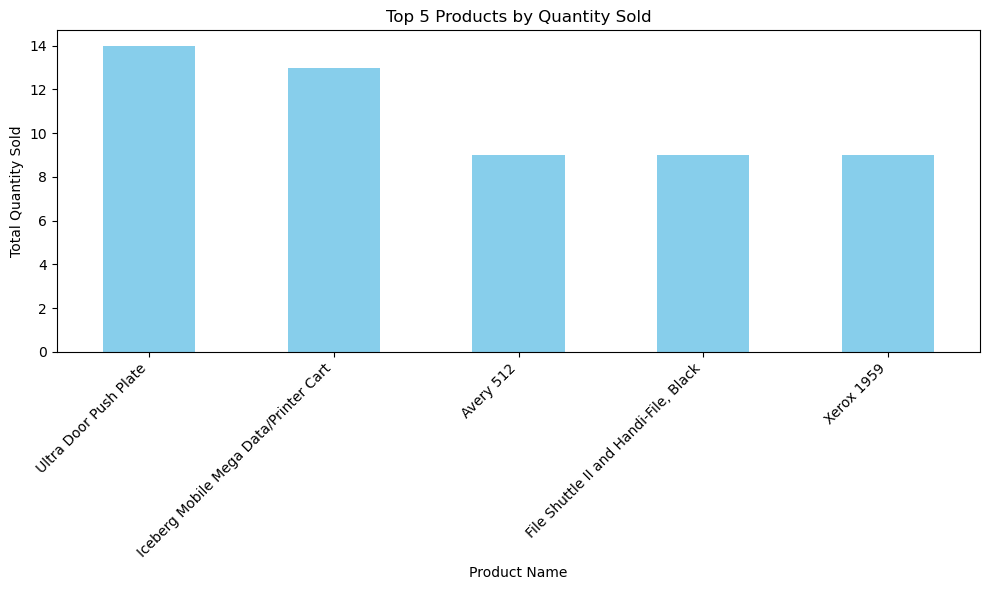

In [84]:
excel_data = pd.ExcelFile("Sales.xlsx")
sales_data = excel_data.parse('Sheet1')
# Plot1: Top 5 Products by Total Quantity Sold
top_products = sales_data.groupby('Product Name')['Quantity'].sum().nlargest(5)

plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 5 Products by Quantity Sold')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_5_products_quantity.png')
plt.show()

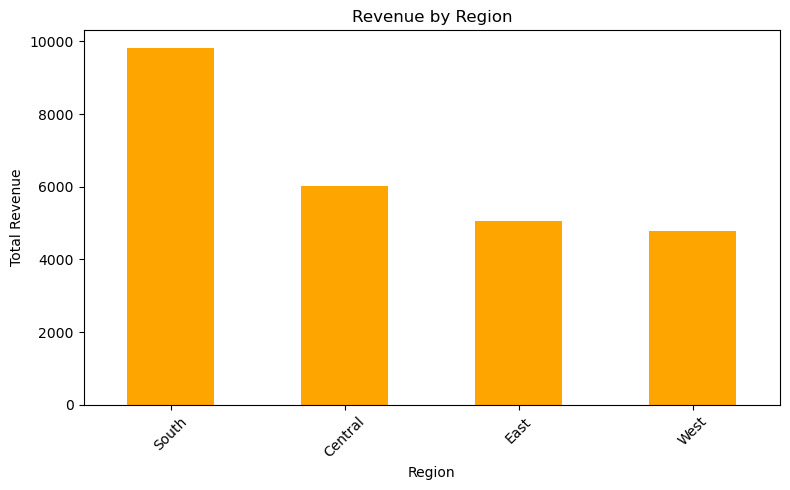

In [86]:
# Plot 2: Revenue by Region
revenue_by_region = sales_data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
revenue_by_region.plot(kind='bar', color='orange')
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_region.png')
plt.show()

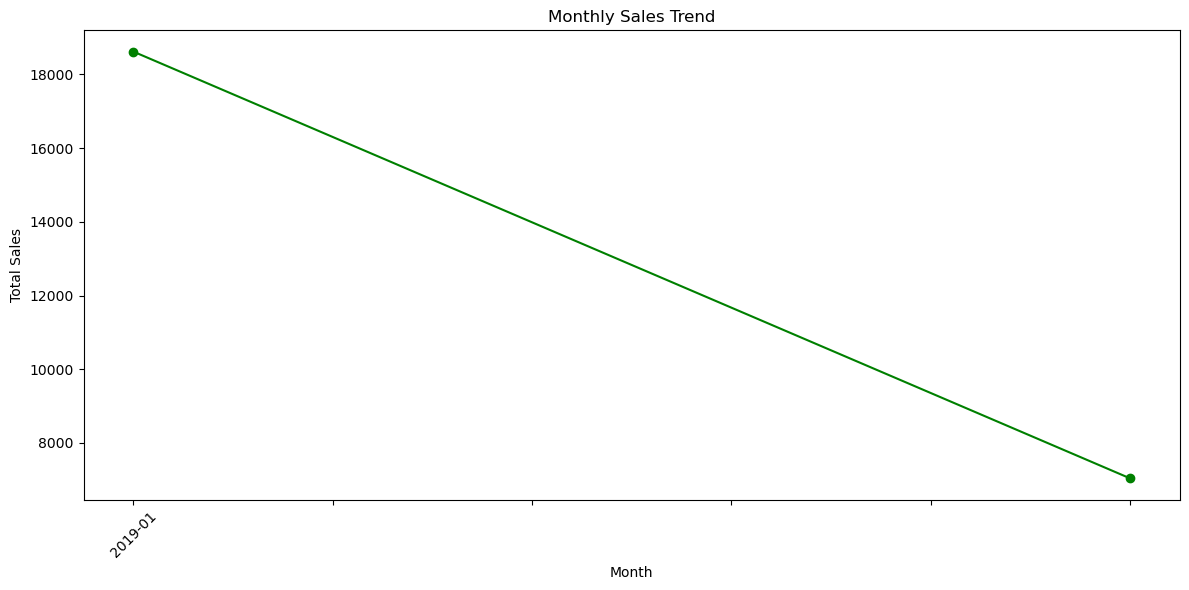

In [90]:
# Plot 3: Monthly Sales Trend
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'])
sales_data['Order_Month'] = sales_data['Order Date'].dt.to_period('M').astype(str)
monthly_sales = sales_data.groupby('Order_Month')['Sales'].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png')
plt.show()

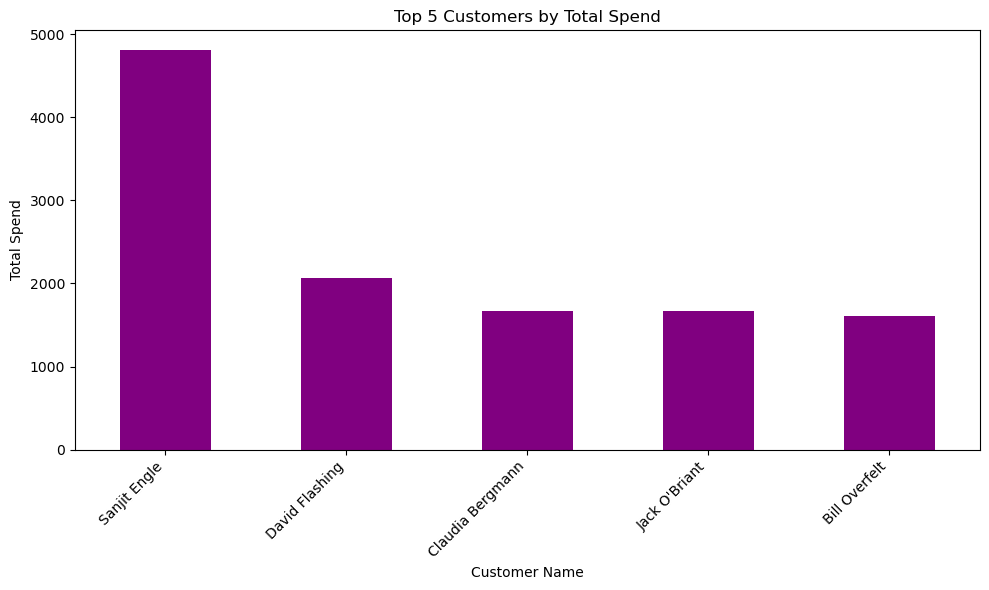

In [92]:
# Plot 4: Top Customers by Spend
top_customers = sales_data.groupby('Customer Name')['Sales'].sum().nlargest(5)
plt.figure(figsize=(10, 6))
top_customers.plot(kind='bar', color='purple')
plt.title('Top 5 Customers by Total Spend')
plt.xlabel('Customer Name')
plt.ylabel('Total Spend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_customers_spend.png')
plt.show()

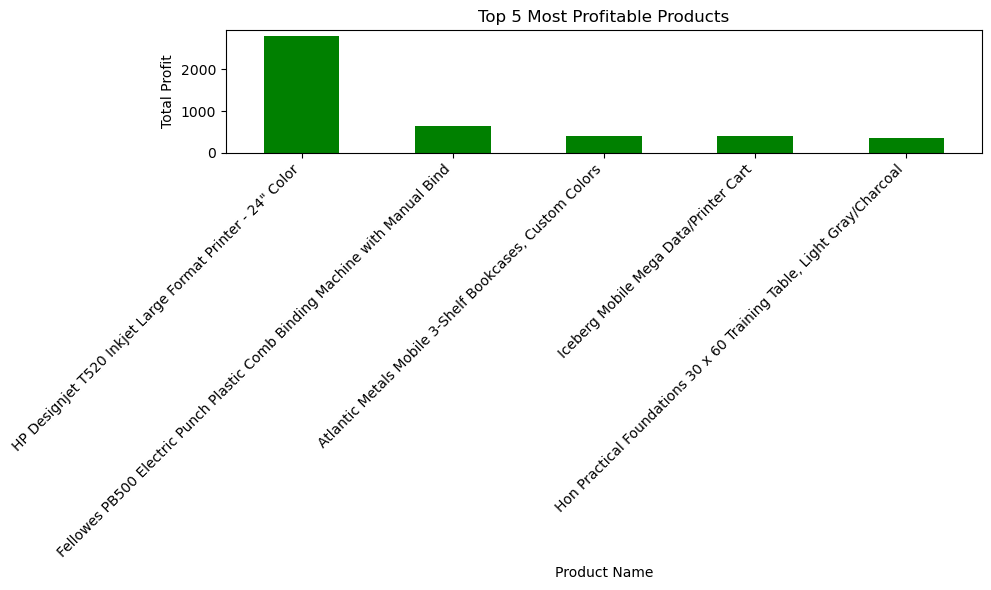

In [94]:
# Plot 5:Most Profitable Products
top_profitable_products = sales_data.groupby('Product Name')['Profit'].sum().nlargest(5)
plt.figure(figsize=(10, 6))
top_profitable_products.plot(kind='bar', color='green')
plt.title('Top 5 Most Profitable Products')
plt.xlabel('Product Name')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_profitable_products.png')
plt.show()


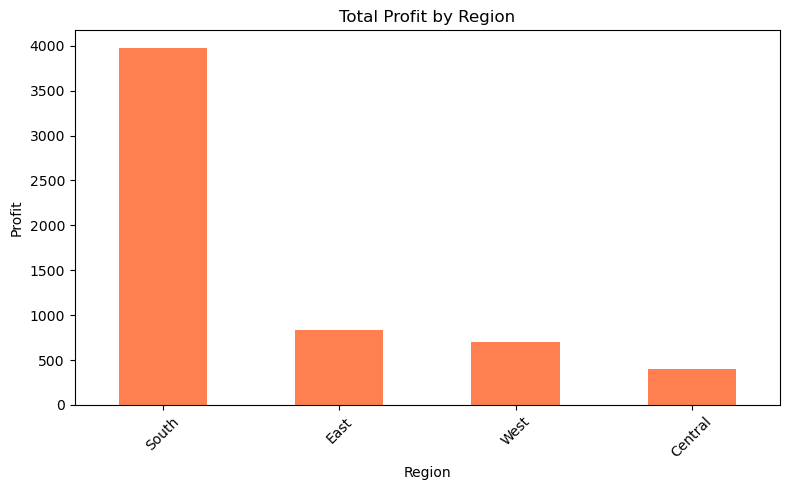

In [96]:
# Plot 6: Top Region by Profit
region_profit = sales_data.groupby('Region')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
region_profit.plot(kind='bar', color='coral')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('profit_by_region.png')
plt.show()